In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import datetime as dt

In [2]:
load_path = Path("../../data/combined/done_week_45")

In [3]:
sold = pd.read_parquet(load_path/"sold.parquet")

In [4]:
sold.columns

Index(['OriginalListPrice', 'CloseDate', 'ClosePrice', 'Latitude', 'Longitude',
       'LivingArea', 'ListPrice', 'DaysOnMarket', 'AssociationFeeFrequency',
       'CountyOrParish', 'ParkingTotal', 'PropertySubType', 'YearBuilt',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal', 'StateOrProvince',
       'FireplaceYN', 'Levels', 'LotSizeArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'GarageSpaces', 'PostalCode', 'AssociationFee',
       'PurchaseContractDate', 'ListingContractDate',
       'ContractStatusChangeDate', 'rate_30yr_fixed', 'ViewYN',
       'PoolPrivateYN', 'MLSAreaMajor', 'ListOfficeName', 'BuyerOfficeName',
       'listing_after_close_flag', 'purchase_after_close_flag',
       'geographic_error'],
      dtype='str')

In [5]:
fe_sold = sold.copy()

fe_sold["PriceRatio"] = np.where(
    fe_sold["OriginalListPrice"] > 0,
    fe_sold["ClosePrice"] / fe_sold["OriginalListPrice"],
    np.nan)
fe_sold["PricePerSqFt"] = np.where(
    fe_sold["LivingArea"] > 0,
    fe_sold["ClosePrice"] / fe_sold["LivingArea"],
    np.nan)

fe_sold["PriceRatio"] = fe_sold["ClosePrice"] / fe_sold["OriginalListPrice"]
fe_sold["PricePerSqFt"] = fe_sold["ClosePrice"] / fe_sold["LivingArea"]

fe_sold["Year"] = fe_sold["CloseDate"].dt.year
fe_sold["Month"] = fe_sold["CloseDate"].dt.month
fe_sold["Year"] = fe_sold["Year"].astype('Int64')
fe_sold["Month"] = fe_sold["Month"].astype('Int64')
fe_sold["YrMo"] = fe_sold["Year"].astype(str) + "-" + fe_sold["Month"].astype(str)

fe_sold["ListingToContractDays"] = (fe_sold["PurchaseContractDate"] - fe_sold["ListingContractDate"]).dt.days
fe_sold["ContractToCloseDays"] = (fe_sold["CloseDate"] - fe_sold["PurchaseContractDate"]).dt.days
fe_sold["ListingToContractDays"] = fe_sold["ListingToContractDays"].astype('Int64')
fe_sold["ContractToCloseDays"] = fe_sold["ContractToCloseDays"].astype('Int64')

<Axes: ylabel='PropertySubType'>

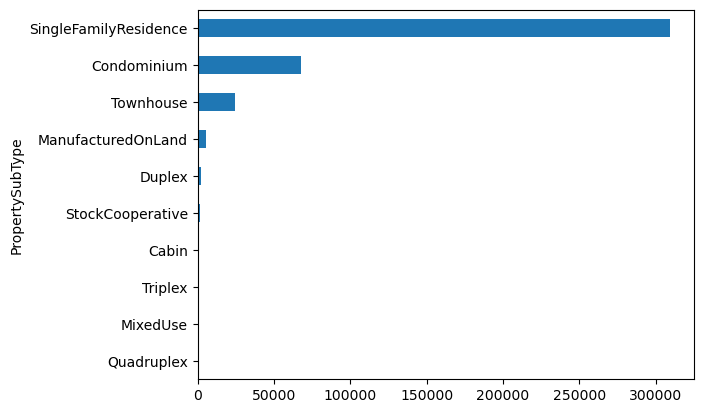

In [6]:
fe_sold["PropertySubType"].value_counts().head(10).sort_values().plot.barh()

<Axes: ylabel='CountyOrParish'>

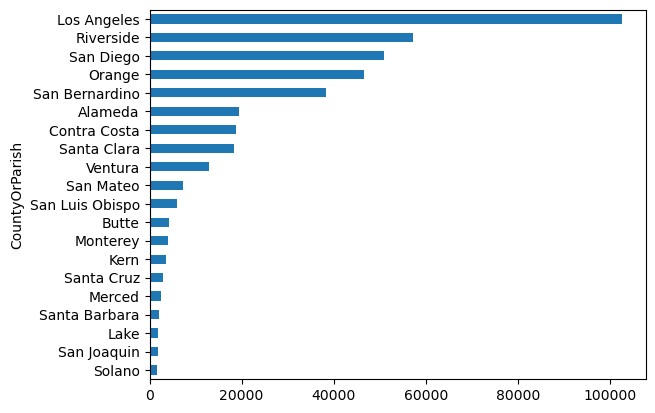

In [7]:
fe_sold["CountyOrParish"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='MLSAreaMajor'>

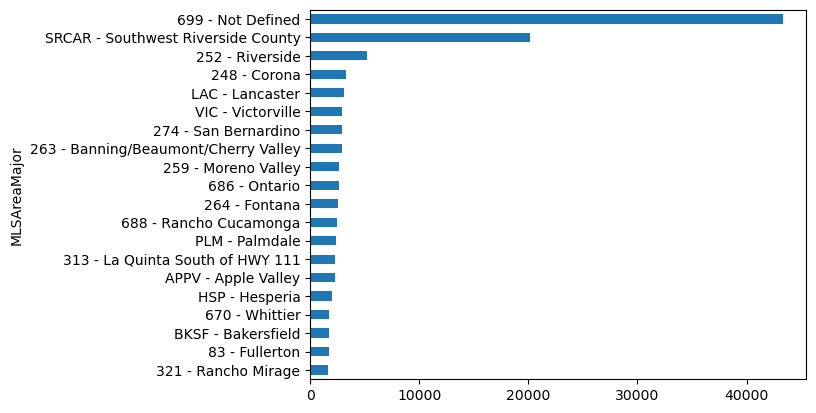

In [8]:
fe_sold["MLSAreaMajor"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='ListOfficeName'>

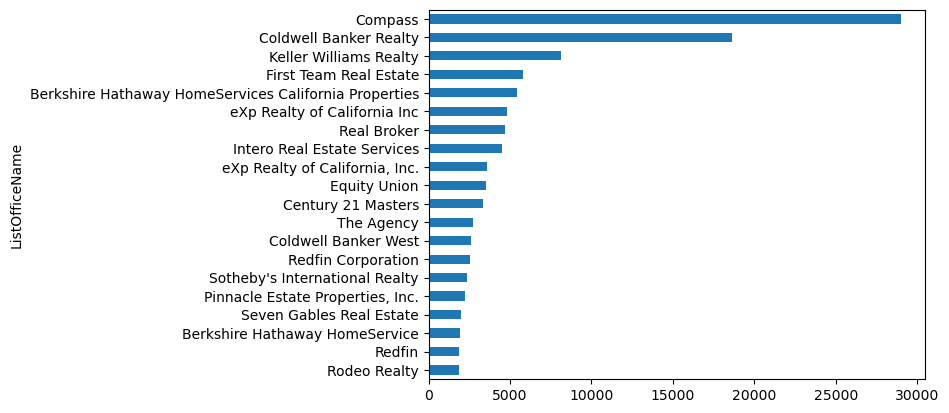

In [9]:
fe_sold["ListOfficeName"].value_counts().head(20).sort_values().plot.barh()

<Axes: ylabel='BuyerOfficeName'>

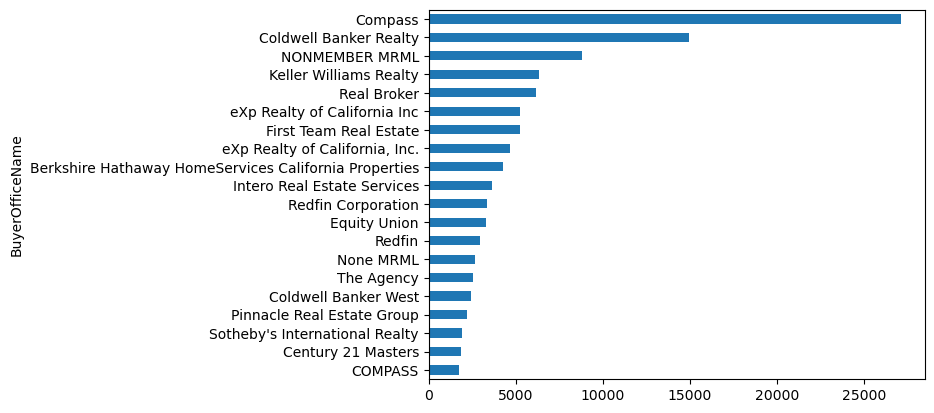

In [10]:
fe_sold["BuyerOfficeName"].value_counts().head(20).sort_values().plot.barh()

In [11]:
summary_by_PropertySubType = (
    fe_sold
    .groupby("PropertySubType")
    .agg(
        listing_count=("PropertySubType", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_PropertySubType.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
PropertySubType,,,,,,,,
SingleFamilyResidence,309461,1.294458e+06,894500.0,637.856583,inf,36.229829,44.275873,31.535536
Condominium,67764,8.794310e+05,630000.0,704.577243,26.028547,41.532436,48.242716,30.931938
Townhouse,24289,1.017917e+06,805000.0,662.665418,41.518181,32.075013,38.313756,30.926812
ManufacturedOnLand,5330,3.524907e+05,325000.0,245.977544,1.291060,58.769794,69.487242,40.556848
Duplex,2263,1.224948e+06,915000.0,639.898642,431.053022,42.390632,54.682722,38.395935
StockCooperative,1659,3.932206e+05,360000.0,406.524549,1.548811,37.856540,48.233273,47.159132
Cabin,380,3.234476e+05,273500.0,696.682462,0.907011,73.876316,82.186842,37.463158
Triplex,336,1.314645e+06,1102500.0,535.505768,1.029005,56.455357,68.916667,45.127976
MixedUse,191,1.030319e+06,725000.0,520.316131,0.888759,83.638743,97.251309,45.502618


In [12]:
summary_by_CountyOrParish = (
    fe_sold
    .groupby("CountyOrParish")
    .agg(
        listing_count=("CountyOrParish", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_CountyOrParish.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
CountyOrParish,,,,,,,,
Los Angeles,102523,1.323177e+06,901000.0,685.041860,109.826222,36.523892,44.785978,34.002784
Riverside,57281,7.203886e+05,600000.0,353.533403,inf,48.378904,59.509459,32.432784
San Diego,50966,1.475049e+06,900000.0,897.165115,1.429632,29.564043,38.294796,29.426419
Orange,46541,1.536265e+06,1175000.0,769.068676,79.625128,31.369760,42.949569,31.125357
San Bernardino,38357,6.011181e+05,535000.0,353.375433,57.539272,45.944782,55.073008,36.940916
Alameda,19440,1.312262e+06,1140000.0,777.098149,1.242234,25.804887,26.81929,25.624846
Contra Costa,18823,1.128721e+06,820000.0,583.748750,1.059882,28.856133,30.166826,26.073903
Santa Clara,18439,1.922961e+06,1600000.0,1066.608460,1.041221,21.854927,22.036661,26.507674
Ventura,12870,1.076200e+06,869250.0,620.001670,1.479415,42.981663,51.91769,25.516788


In [13]:
summary_by_BuyerOfficeName = (
    fe_sold
    .groupby("BuyerOfficeName")
    .agg(
        listing_count=("CountyOrParish", "size"),
        avg_close_price=("ClosePrice", "mean"),
        median_close_price=("ClosePrice", "median"),
        avg_price_per_sqft=("PricePerSqFt", "mean"),
        avg_price_ratio=("PriceRatio", "mean"),
        avg_days_on_market=("DaysOnMarket", "mean"),
        avg_listing_to_contract_days=("ListingToContractDays", "mean"),
        avg_contract_to_close_days=("ContractToCloseDays", "mean")
    )
    .sort_values("listing_count", ascending=False)
)

summary_by_BuyerOfficeName.head(10)

,listing_count,avg_close_price,median_close_price,avg_price_per_sqft,avg_price_ratio,avg_days_on_market,avg_listing_to_contract_days,avg_contract_to_close_days
BuyerOfficeName,,,,,,,,
Compass,27104,1.798366e+06,1330000.0,851.731542,1.564801,32.011880,37.546086,27.158373
Coldwell Banker Realty,14917,1.717981e+06,1198000.0,873.176295,1.409588,34.486492,41.267373,27.450295
NONMEMBER MRML,8826,6.371933e+05,503425.5,359.775219,inf,48.629957,57.910492,37.234874
Keller Williams Realty,6354,1.270947e+06,835000.0,794.464024,1.748225,34.638653,43.065953,29.921612
Real Broker,6142,1.021326e+06,800000.0,584.714065,1.167267,33.535005,44.0298,30.150138
eXp Realty of California Inc,5257,1.046288e+06,835000.0,618.987244,1.183851,36.860186,43.723692,30.580971
First Team Real Estate,5230,1.092101e+06,900000.0,613.643629,187.546401,31.200574,42.492349,30.441278
"eXp Realty of California, Inc.",4685,9.831173e+05,730000.0,626.826177,1.455668,34.194237,43.714408,30.829029
Berkshire Hathaway HomeServices California Properties,4248,1.489940e+06,975000.0,701.994612,1.208075,39.239407,47.034906,29.891274
